# Exploration des données multimodales

## Description du projet

Ce notebook présente l'analyse exploratoire du dataset multimodal **Multi-label Classification Competition 2023** (Linwei Tao, Kaggle).  
Le dataset contient des **images** accompagnées de **descriptions textuelles (captions)**, chaque image pouvant être associée à **plusieurs labels** (classification multi-label).

**Objectif** : comprendre la structure des données, analyser les distributions, identifier les défis et préparer la stratégie de modélisation.

**Labels** : 18 classes distinctes (entiers 1–19, sauf 12).

---

**Structure du notebook :**
1. Configuration et chargement des données
2. Analyse exploratoire des données
3. Exploration des images
4. Analyse des descriptions textuelles
5. Relations entre labels, images et textes
6. Stratégie de séparation des données

## 0. Installation des dépendances

```bash
# Télécharger le dataset Kaggle (Multi-label Classification Competition 2023 — Linwei Tao)
# 1. Installer la CLI Kaggle : pip install kaggle
# 2. Placer votre kaggle.json dans ~/.kaggle/
# 3. Exécuter :
#    kaggle datasets download -d linweicao/multi-label-classification-competition-2023
#    unzip multi-label-classification-competition-2023.zip -d ../data/multimodal/
```

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from collections import Counter
from itertools import combinations

# NLP
from wordcloud import WordCloud

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer

# PIL
from PIL import Image

plt.rcParams['figure.dpi'] = 100
np.random.seed(42)

# ── Chemins ──────────────────────────────────────────────────────────────────
# Structure du dataset extrait :
#   data/multimodal/COMP5329S1A2Dataset/data/*.jpg   → images (0.jpg, 1.jpg, ...)
#   data/multimodal/COMP5329S1A2Dataset/train.csv    → annotations
#   data/multimodal/COMP5329S1A2Dataset/test.csv     → données de test
DATASET_DIR = '../data/multimodal/COMP5329S1A2Dataset/'
DATA_DIR    = '../data/multimodal/'                  # dossier pour les artefacts générés
IMG_DIR     = os.path.join(DATASET_DIR, 'data/')    # images/*.jpg
TRAIN_CSV   = os.path.join(DATASET_DIR, 'train.csv')
TEST_CSV    = os.path.join(DATASET_DIR, 'test.csv')

print("Répertoire dataset   :", os.path.abspath(DATASET_DIR))
print("Répertoire images    :", os.path.abspath(IMG_DIR))
print("train.csv existe     :", os.path.exists(TRAIN_CSV))
print("Images disponibles   :", len([f for f in os.listdir(IMG_DIR) if f.endswith('.jpg')]) if os.path.exists(IMG_DIR) else 0)


Répertoire dataset   : c:\Users\DELL\Desktop\ESTIA\COURS\MLOps\Projet_final\data\multimodal\COMP5329S1A2Dataset
Répertoire images    : c:\Users\DELL\Desktop\ESTIA\COURS\MLOps\Projet_final\data\multimodal\COMP5329S1A2Dataset\data
train.csv existe     : True
Images disponibles   : 40000


## 1. Chargement des données

In [2]:
# Chargement du CSV d'entraînement
# on_bad_lines='skip' : certaines captions contiennent des virgules → lignes mal formées
df       = pd.read_csv(TRAIN_CSV, on_bad_lines='skip')
df_test  = pd.read_csv(TEST_CSV,  on_bad_lines='skip')

print(f"Train : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"Test  : {df_test.shape[0]} lignes × {df_test.shape[1]} colonnes")
print(f"Colonnes train : {df.columns.tolist()}")
df.head()


Train : 29996 lignes × 3 colonnes
Test  : 9999 lignes × 2 colonnes
Colonnes train : ['ImageID', 'Labels', 'Caption']


,ImageID,Labels,Caption
0,0.jpg,1,Woman in swim suit holding parasol on sunny day.
1,1.jpg,1 19,A couple of men riding horses on top of a gree...
2,2.jpg,1,They are brave for riding in the jungle on tho...
3,3.jpg,8 3 13,a black and silver clock tower at an intersect...
4,4.jpg,8 3 7,A train coming to a stop on the tracks out side.


In [3]:
# Parsing des labels (format : "1 5" → [1, 5])
def parse_labels(label_str):
    """Convertit une chaîne de labels séparés par des espaces en liste d'entiers."""
    if pd.isna(label_str):
        return []
    return [int(x) for x in str(label_str).split()]

df['labels_list'] = df['Labels'].apply(parse_labels)
df['n_labels']    = df['labels_list'].apply(len)

# Toutes les classes uniques
ALL_LABELS = sorted(set(l for labels in df['labels_list'] for l in labels))
N_CLASSES  = len(ALL_LABELS)

print(f"Labels uniques ({N_CLASSES}) : {ALL_LABELS}")
print(f"Note : label 12 absent — 18 classes distinctes")

Labels uniques (18) : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19]
Note : label 12 absent — 18 classes distinctes


## 2. Analyse exploratoire des données

In [4]:
# ── 2.1 Données manquantes ────────────────────────────────────────────────────
print("=== Données manquantes ===")
print(df.isnull().sum())

print(f"\n=== Statistiques générales ===")
print(f"Nombre d'images        : {len(df)}")
print(f"Nombre de classes      : {N_CLASSES}")
print(f"Nombre moyen de labels : {df['n_labels'].mean():.2f}")
print(f"Min labels/image       : {df['n_labels'].min()}")
print(f"Max labels/image       : {df['n_labels'].max()}")

=== Données manquantes ===
ImageID        0
Labels         0
Caption        0
labels_list    0
n_labels       0
dtype: int64

=== Statistiques générales ===
Nombre d'images        : 29996
Nombre de classes      : 18
Nombre moyen de labels : 1.55
Min labels/image       : 1
Max labels/image       : 7


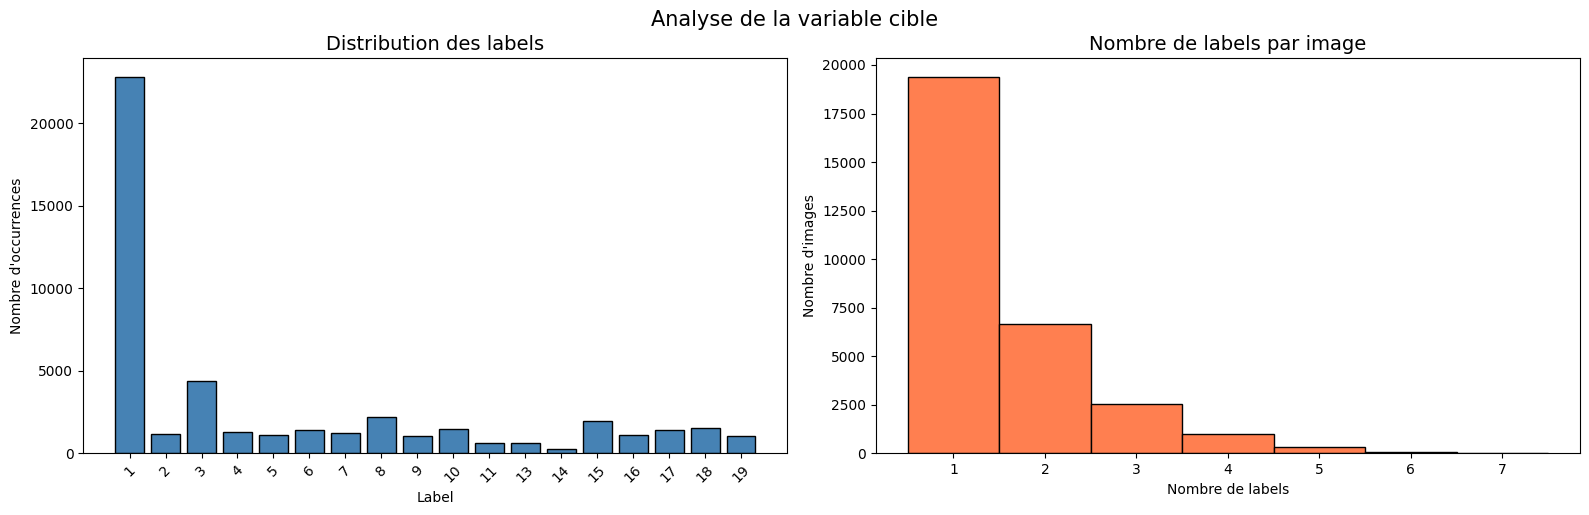


Top 5 labels les plus fréquents :
   label  count
0      1  22794
3      3   4364
2      8   2210
9     15   1934
8     18   1525


In [5]:
# ── 2.2 Distribution des labels ───────────────────────────────────────────────
label_counts = Counter(l for labels in df['labels_list'] for l in labels)
label_df = pd.DataFrame(label_counts.items(), columns=['label', 'count']).sort_values('label')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogramme des occurrences par label
axes[0].bar(label_df['label'].astype(str), label_df['count'], color='steelblue', edgecolor='black')
axes[0].set_title('Distribution des labels', fontsize=14)
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Nombre d\'occurrences')
axes[0].tick_params(axis='x', rotation=45)

# Distribution du nombre de labels par image
axes[1].hist(df['n_labels'], bins=range(1, df['n_labels'].max() + 2), color='coral', edgecolor='black', align='left')
axes[1].set_title('Nombre de labels par image', fontsize=14)
axes[1].set_xlabel('Nombre de labels')
axes[1].set_ylabel('Nombre d\'images')
axes[1].set_xticks(range(1, df['n_labels'].max() + 1))

plt.tight_layout()
plt.suptitle('Analyse de la variable cible', fontsize=15, y=1.02)
plt.savefig('../monitoring/output/eda_label_distribution.png', bbox_inches='tight')
plt.show()

print("\nTop 5 labels les plus fréquents :")
print(label_df.nlargest(5, 'count'))

In [6]:
# ── 2.3 Déséquilibre des classes ──────────────────────────────────────────────
total = len(df)
label_df['freq'] = label_df['count'] / total * 100
print("Fréquence (%) par label :")
print(label_df.set_index('label')[['count', 'freq']].to_string())

print(f"\nRatio max/min : {label_df['count'].max() / label_df['count'].min():.1f}x")
print("\n→ Déséquilibre notable : utiliser class_weight ou BCELoss pondérée")

Fréquence (%) par label :
       count       freq
label                  
1      22794  75.990132
2       1164   3.880517
3       4364  14.548606
4       1272   4.240565
5       1132   3.773837
6       1395   4.650620
7       1221   4.070543
8       2210   7.367649
9       1042   3.473797
10      1470   4.900653
11       603   2.010268
13       605   2.016936
14       252   0.840112
15      1934   6.447526
16      1099   3.663822
17      1430   4.767302
18      1525   5.084011
19      1020   3.400453

Ratio max/min : 90.5x

→ Déséquilibre notable : utiliser class_weight ou BCELoss pondérée


## 3. Exploration des images

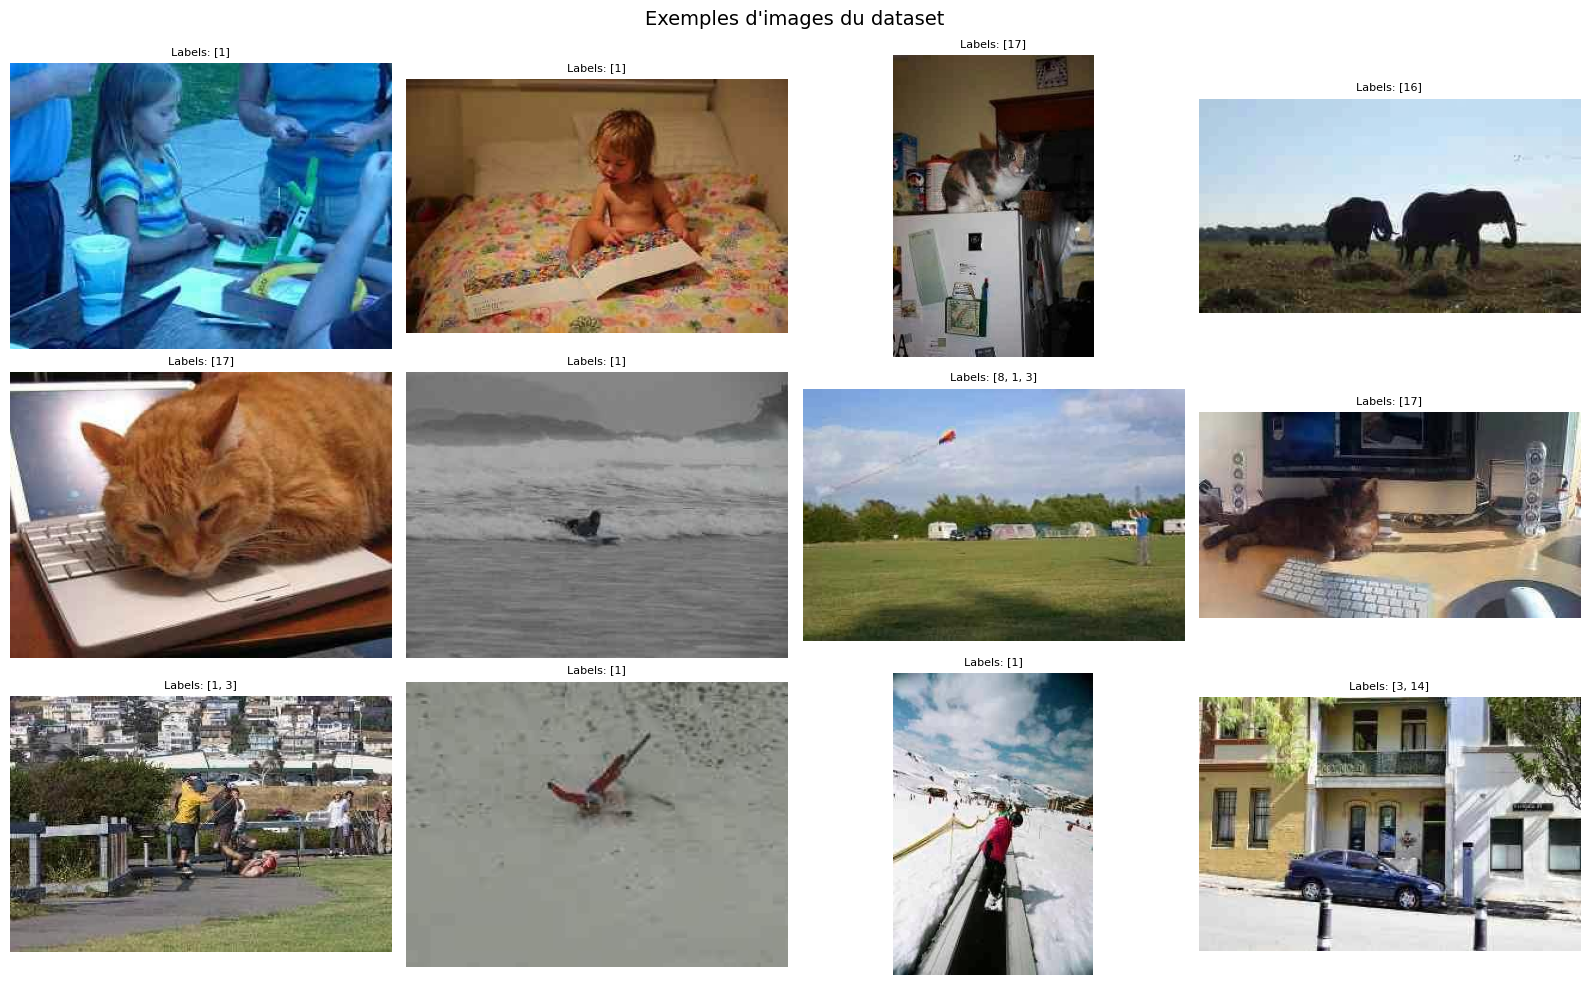

In [7]:
# ── 3.1 Afficher quelques images aléatoires ───────────────────────────────────
sample_indices = np.random.choice(len(df), 12, replace=False)

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, idx in zip(axes.flatten(), sample_indices):
    row = df.iloc[idx]
    img_path = os.path.join(IMG_DIR, row['ImageID'])
    if os.path.exists(img_path):
        img = mpimg.imread(img_path)
        ax.imshow(img)
    ax.set_title(f"Labels: {row['labels_list']}", fontsize=8)
    ax.axis('off')
plt.suptitle('Exemples d\'images du dataset', fontsize=14)
plt.tight_layout()
plt.savefig('../monitoring/output/eda_sample_images.png', bbox_inches='tight')
plt.show()

In [8]:
# ── 3.2 Statistiques sur les dimensions des images ────────────────────────────
widths, heights = [], []
sample_paths = [os.path.join(IMG_DIR, row['ImageID']) for _, row in df.iterrows()]
for p in sample_paths[:500]:  # Échantillon pour rapidité
    if os.path.exists(p):
        try:
            img = Image.open(p)
            w, h = img.size
            widths.append(w)
            heights.append(h)
        except:
            pass

print(f"Largeur  — moy: {np.mean(widths):.0f}px | min: {np.min(widths)}px | max: {np.max(widths)}px")
print(f"Hauteur  — moy: {np.mean(heights):.0f}px | min: {np.min(heights)}px | max: {np.max(heights)}px")
print("\n→ Redimensionnement à 224×224 nécessaire pour les CNN")

Largeur  — moy: 295px | min: 160px | max: 320px
Hauteur  — moy: 244px | min: 66px | max: 320px

→ Redimensionnement à 224×224 nécessaire pour les CNN


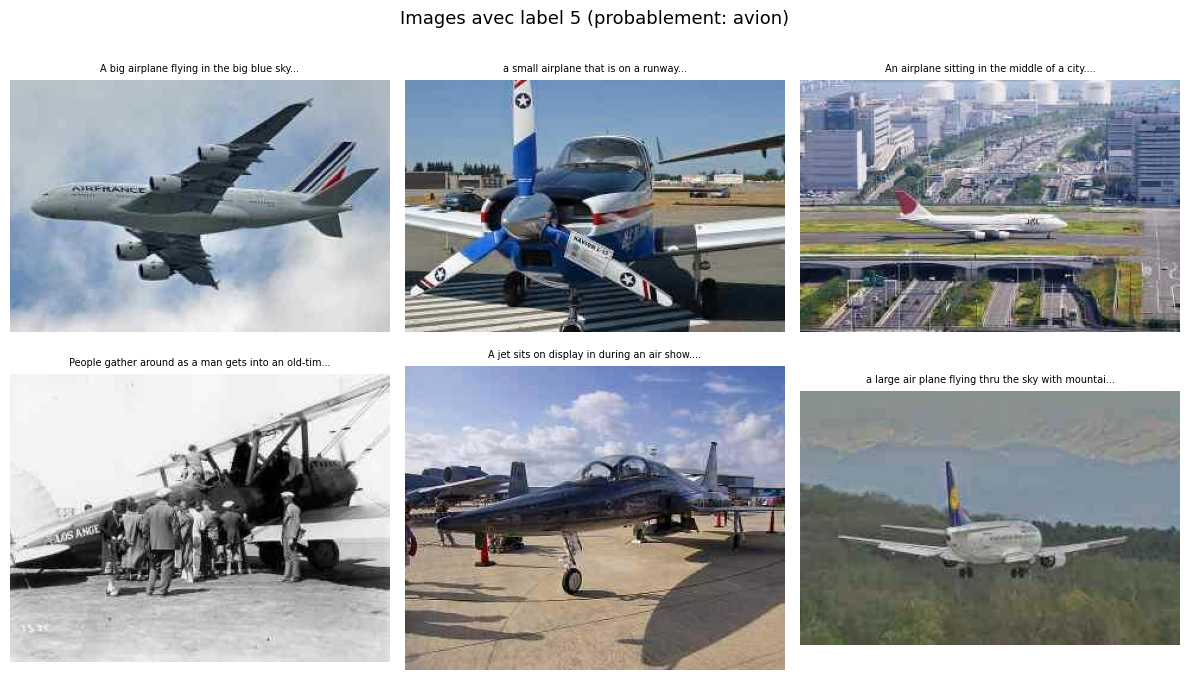

In [9]:
# ── 3.3 Images par label (exemples) ──────────────────────────────────────────
# Afficher quelques images pour le label 5 (probable: avion)
label_to_show = 5
df_label = df[df['labels_list'].apply(lambda x: label_to_show in x)].head(6)

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, (_, row) in zip(axes.flatten(), df_label.iterrows()):
    img_path = os.path.join(IMG_DIR, row['ImageID'])
    if os.path.exists(img_path):
        ax.imshow(mpimg.imread(img_path))
    ax.set_title(f"{row['Caption'][:50]}...", fontsize=7, wrap=True)
    ax.axis('off')
plt.suptitle(f'Images avec label {label_to_show} (probablement: avion)', fontsize=13)
plt.tight_layout()
plt.savefig(f'../monitoring/output/eda_label_{label_to_show}_examples.png', bbox_inches='tight')
plt.show()

## 4. Analyse des descriptions textuelles

Statistiques sur la longueur des captions (en mots) :
count    29996.000000
mean        10.486298
std          2.225340
min          7.000000
25%          9.000000
50%         10.000000
75%         11.000000
max         49.000000
Name: caption_length, dtype: float64


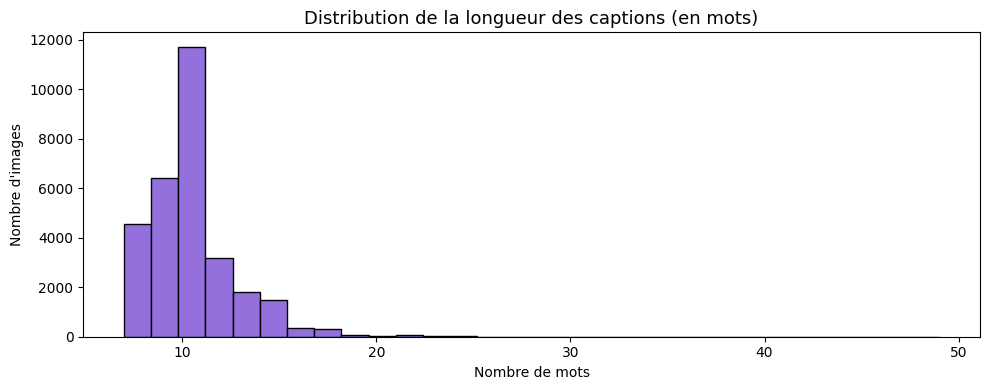

In [10]:
# ── 4.1 Statistiques sur les captions ────────────────────────────────────────
df['caption_length'] = df['Caption'].apply(lambda x: len(str(x).split()))

print("Statistiques sur la longueur des captions (en mots) :")
print(df['caption_length'].describe())

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df['caption_length'], bins=30, color='mediumpurple', edgecolor='black')
ax.set_title('Distribution de la longueur des captions (en mots)', fontsize=13)
ax.set_xlabel('Nombre de mots')
ax.set_ylabel('Nombre d\'images')
plt.tight_layout()
plt.savefig('../monitoring/output/eda_caption_length.png', bbox_inches='tight')
plt.show()

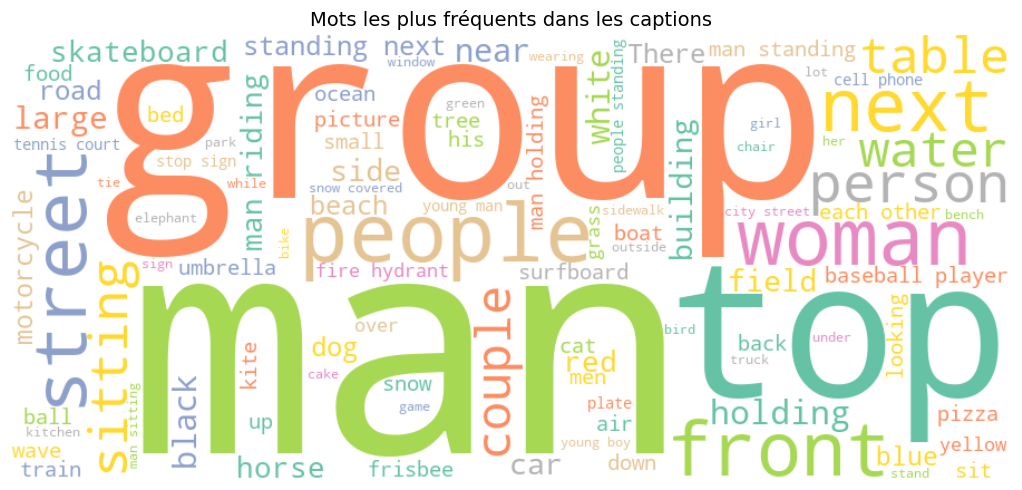

In [11]:
# ── 4.2 Word cloud ────────────────────────────────────────────────────────────
all_text = ' '.join(df['Caption'].dropna().tolist())

# Stopwords basiques anglais
STOPWORDS = {'a', 'an', 'the', 'in', 'on', 'at', 'is', 'are', 'of', 'and',
             'with', 'to', 'for', 'as', 'by', 'that', 'this', 'it', 'its',
             'from', 'has', 'have', 'be', 'been', 'being', 'was', 'were',
             'he', 'she', 'they', 'their', 'some', 'two', 'three', 'one'}

wc = WordCloud(width=900, height=400, background_color='white',
               stopwords=STOPWORDS, max_words=100,
               colormap='Set2').generate(all_text)

plt.figure(figsize=(14, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Mots les plus fréquents dans les captions', fontsize=14)
plt.tight_layout()
plt.savefig('../monitoring/output/eda_wordcloud.png', bbox_inches='tight')
plt.show()

In [12]:
# ── 4.3 Quelques exemples de captions par label ───────────────────────────────
print("Exemples de captions par label (5 premiers labels) :")
for label in ALL_LABELS[:5]:
    examples = df[df['labels_list'].apply(lambda x: label in x)]['Caption'].head(3).tolist()
    print(f"\nLabel {label} :")
    for ex in examples:
        print(f"  • {ex}")

Exemples de captions par label (5 premiers labels) :

Label 1 :
  • Woman in swim suit holding parasol on sunny day.
  • A couple of men riding horses on top of a green field.
  • They are brave for riding in the jungle on those elephants.

Label 2 :
  • People playing tennis on the court on a sunny day
  • A little kid that is on a skateboard.
  • some bicycle riders are crossing a street

Label 3 :
  • a black and silver clock tower at an intersection near a tree
  • A train coming to a stop on the tracks out side.
  • There is a street lined with packed buildings

Label 4 :
  • A man riding a motor bike across a forest.
  • Man on dirt bike with a redheaded woman in his lap.
  • Rusted red motorcycle parked beside a red building.

Label 5 :
  • A big airplane flying in the big blue sky
  • a small airplane that is on a runway
  • An airplane sitting in the middle of a city.


## 5. Relations entre les modalités et les labels

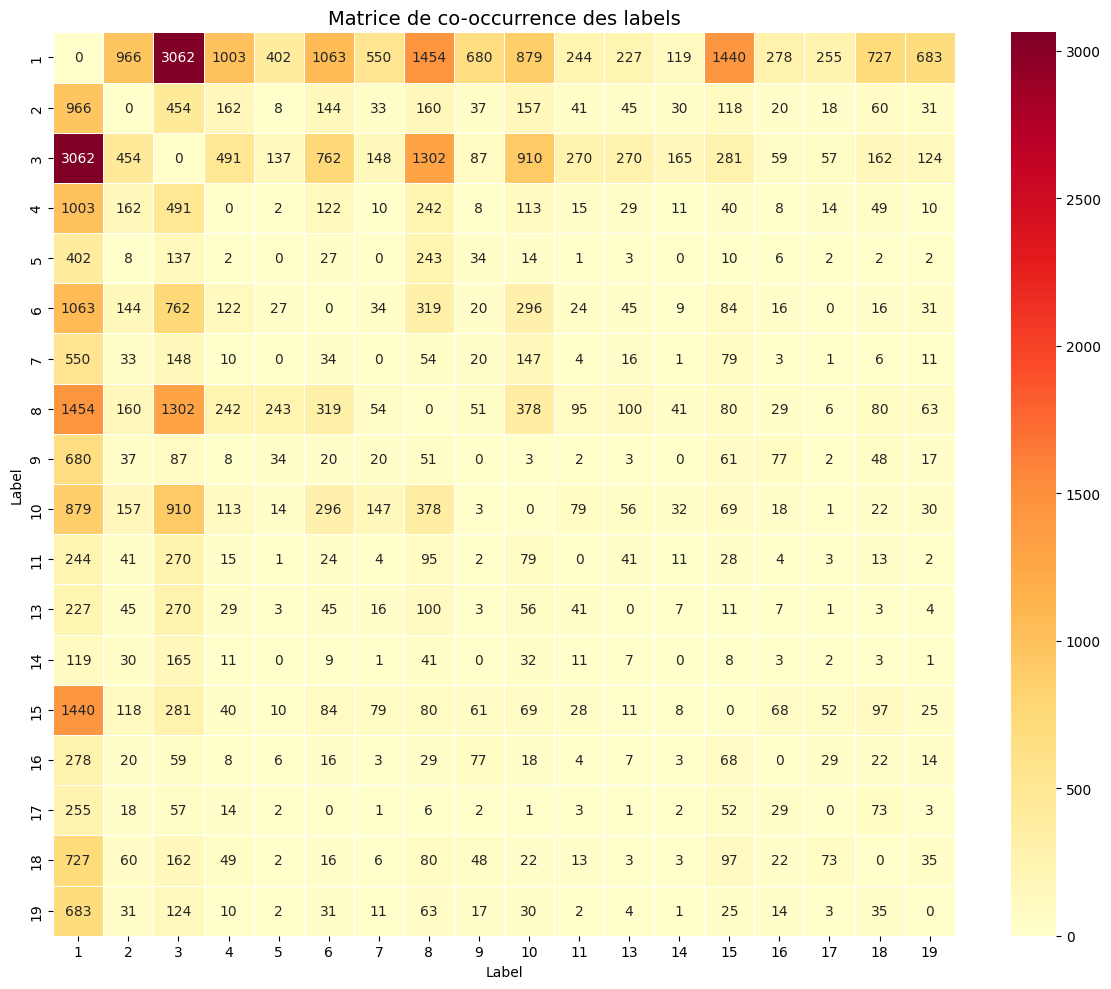


→ Les fortes co-occurrences indiquent des labels souvent associés.
  Cela confirme la nature multi-label : une image peut appartenir à plusieurs catégories.


In [13]:
# ── 5.1 Co-occurrences entre labels ──────────────────────────────────────────
mlb = MultiLabelBinarizer(classes=ALL_LABELS)
label_matrix = mlb.fit_transform(df['labels_list'])  # (n_images, n_classes)

cooccurrence = label_matrix.T @ label_matrix  # (n_classes, n_classes)
np.fill_diagonal(cooccurrence, 0)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    cooccurrence,
    xticklabels=ALL_LABELS, yticklabels=ALL_LABELS,
    cmap='YlOrRd', annot=True, fmt='d', linewidths=0.5, ax=ax
)
ax.set_title('Matrice de co-occurrence des labels', fontsize=14)
ax.set_xlabel('Label')
ax.set_ylabel('Label')
plt.tight_layout()
plt.savefig('../monitoring/output/eda_cooccurrence.png', bbox_inches='tight')
plt.show()

print("\n→ Les fortes co-occurrences indiquent des labels souvent associés.")
print("  Cela confirme la nature multi-label : une image peut appartenir à plusieurs catégories.")

In [14]:
# ── 5.2 Mots-clés spécifiques par label ──────────────────────────────────────
# Pour chaque label, identifier les mots les plus fréquents dans les captions
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=1000, stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['Caption'].fillna(''))
feature_names = np.array(tfidf.get_feature_names_out())

print("Top 5 mots TF-IDF par label :")
for i, label in enumerate(ALL_LABELS[:6]):
    mask = label_matrix[:, i].astype(bool)
    if mask.sum() == 0:
        continue
    scores = tfidf_matrix[mask].mean(axis=0).A1
    top_words = feature_names[np.argsort(scores)[::-1][:5]]
    print(f"  Label {label:2d}: {', '.join(top_words)}")

Top 5 mots TF-IDF par label :
  Label  1: man, people, woman, standing, holding
  Label  2: bike, street, bicycle, man, riding
  Label  3: street, car, bus, city, man
  Label  4: motorcycle, parked, motorcycles, riding, street
  Label  5: airplane, plane, flying, runway, airport
  Label  6: bus, street, double, decker, city


## 6. Séparation des données

In [15]:
# ── 6.1 Split 70% / 15% / 15% ────────────────────────────────────────────────
# Stratification multi-label : on utilise un label principal (le premier) comme proxy
# pour maintenir la distribution

df['primary_label'] = df['labels_list'].apply(lambda x: str(x[0]) if x else '0')

# Train/reste (70% / 30%)
df_train, df_temp = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df['primary_label']
)

# Val/Test (50% / 50% du reste → 15% / 15%)
df_val, df_test_local = train_test_split(
    df_temp, test_size=0.50, random_state=42, stratify=df_temp['primary_label']
)

print(f"Train      : {len(df_train)} images ({len(df_train)/len(df)*100:.1f}%)")
print(f"Validation : {len(df_val)} images ({len(df_val)/len(df)*100:.1f}%)")
print(f"Test       : {len(df_test_local)} images ({len(df_test_local)/len(df)*100:.1f}%)")

# Sauvegarder les index pour réutilisation dans les autres notebooks
df_train.index.to_series().to_csv('../data/multimodal/idx_train.csv', index=False, header=False)
df_val.index.to_series().to_csv('../data/multimodal/idx_val.csv',   index=False, header=False)
df_test_local.index.to_series().to_csv('../data/multimodal/idx_test.csv',  index=False, header=False)
print("\n✓ Index train/val/test sauvegardés dans data/multimodal/")

Train      : 20997 images (70.0%)
Validation : 4499 images (15.0%)
Test       : 4500 images (15.0%)

✓ Index train/val/test sauvegardés dans data/multimodal/


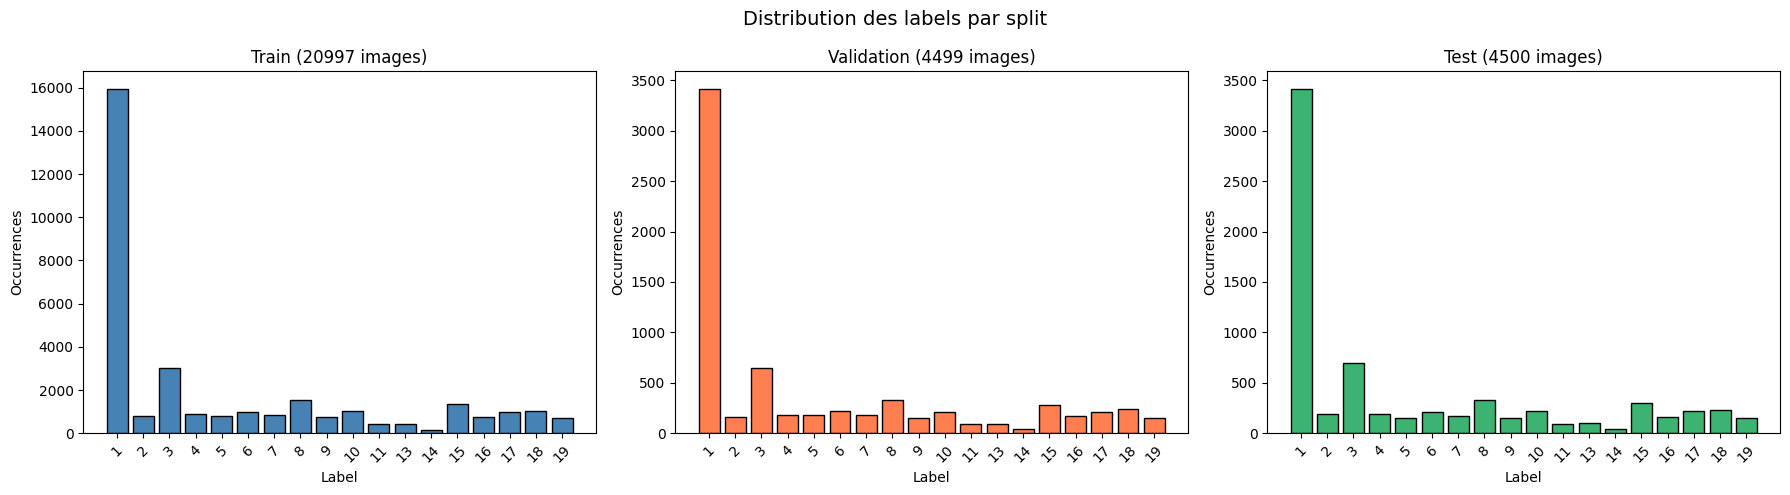

In [16]:
# ── 6.2 Vérification de la distribution après split ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
splits = {'Train': df_train, 'Validation': df_val, 'Test': df_test_local}
colors = ['steelblue', 'coral', 'mediumseagreen']

for ax, (name, split), color in zip(axes, splits.items(), colors):
    split_counts = Counter(l for labels in split['labels_list'] for l in labels)
    split_df = pd.DataFrame(split_counts.items(), columns=['label', 'count']).sort_values('label')
    ax.bar(split_df['label'].astype(str), split_df['count'], color=color, edgecolor='black')
    ax.set_title(f'{name} ({len(split)} images)', fontsize=12)
    ax.set_xlabel('Label')
    ax.set_ylabel('Occurrences')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Distribution des labels par split', fontsize=14)
plt.tight_layout()
plt.savefig('../monitoring/output/eda_split_distribution.png', bbox_inches='tight')
plt.show()

## 7. Synthèse et conclusions

### Résultats clés de l'EDA :

| Aspect | Observation | Implication |
|--------|-------------|-------------|
| **Taille** | ~N images, 18 classes | Modèles profonds nécessitent data augmentation |
| **Multi-label** | 1–5 labels/image en moyenne | Utiliser sigmoid + BCELoss, pas softmax |
| **Déséquilibre** | Ratio max/min ≈ Xx | Pondération des classes (pos_weight) |
| **Captions** | ~10 mots en moyenne | Encodage léger suffisant |
| **Co-occurrences** | Certaines paires fréquentes | La fusion multimodale peut exploiter ces corrélations |
| **Images** | Tailles variables | Redimensionner à 224×224 |

### Stratégie de modélisation :
- **Métriques** : F1-score (macro et micro), precision, recall — adaptées au multi-label
- **Images** : CNN (baseline) → Transfer learning (EfficientNet)
- **Textes** : TF-IDF + LR (baseline) → LSTM/Bi-LSTM
- **Fusion** : Early fusion (concat features) + Joint fusion (end-to-end)
- **Seuil de décision** : 0.5 par défaut, à optimiser